In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [5]:
df1 = pd.read_csv('/content/powerconsumption.csv')
df = pd.DataFrame(df1)
df.head(6)


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964
5,1/1/2017 0:50,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048


### Sample Input for LSTM Model Prediction

In [6]:
df.isnull().sum()

,0
Datetime,0
Temperature,0
Humidity,0
WindSpeed,0
GeneralDiffuseFlows,0
DiffuseFlows,0
PowerConsumption_Zone1,0
PowerConsumption_Zone2,0
PowerConsumption_Zone3,0


In [7]:
df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [9]:
df.shape

(52416, 9)

In [10]:
df["TotalConsumption"] = (
    df["PowerConsumption_Zone1"] +
    df["PowerConsumption_Zone2"] +
    df["PowerConsumption_Zone3"]
)

In [11]:
import random

# The features the model expects, in the correct order
features_for_prediction = [
    'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows',
    'lag_1', 'lag_6', 'lag_144', 'lag_1008', 'TotalConsumption'
]

# Define the number of steps (look-back window) the LSTM was trained with
# This should match the 'n_steps' used during model training
lstm_n_steps = 10

# Create a list of 'lstm_n_steps' sample observations
sample_input_sequence = []
for _ in range(lstm_n_steps):
    # Generate plausible random values for each feature
    # These ranges are illustrative and should ideally reflect your dataset's distribution
    observation = {
        'Temperature': random.uniform(5.0, 35.0), # Example range
        'Humidity': random.uniform(40.0, 90.0),   # Example range
        'WindSpeed': random.uniform(0.1, 5.0),    # Example range
        'GeneralDiffuseFlows': random.uniform(0.0, 500.0), # Example range
        'DiffuseFlows': random.uniform(0.0, 200.0),      # Example range
        'lag_1': random.uniform(20000.0, 80000.0), # Example range for PowerConsumption_Zone1
        'lag_6': random.uniform(20000.0, 80000.0), # Example range for PowerConsumption_Zone1
        'lag_144': random.uniform(20000.0, 80000.0), # Example range for PowerConsumption_Zone1
        'lag_1008': random.uniform(20000.0, 80000.0),# Example range for PowerConsumption_Zone1
        'TotalConsumption': random.uniform(40000.0, 100000.0) # Example range for the target
    }
    sample_input_sequence.append(observation)

print("Sample Input Sequence (first 2 observations shown for brevity):")
for i, obs in enumerate(sample_input_sequence):
    if i < 2 or i >= lstm_n_steps - 2: # Show first two and last two
        print(f"Observation {i+1}: {obs}")
    elif i == 2 and lstm_n_steps > 4:
        print("...")

# The full sequence can be printed if needed
# import json
# print(json.dumps(sample_input_sequence, indent=2))

# Note: This `sample_input_sequence` is what you would send in a POST request
# to your Flask/FastAPI endpoint, typically as a JSON array.

Sample Input Sequence (first 2 observations shown for brevity):
Observation 1: {'Temperature': 26.40118638097514, 'Humidity': 84.33167774460591, 'WindSpeed': 2.138559868533652, 'GeneralDiffuseFlows': 478.62866399888134, 'DiffuseFlows': 92.70258538323081, 'lag_1': 54576.839608584014, 'lag_6': 43618.07195556638, 'lag_144': 38530.31795906694, 'lag_1008': 67076.49739026185, 'TotalConsumption': 82319.5526730394}
Observation 2: {'Temperature': 7.910831840546368, 'Humidity': 74.72725939925621, 'WindSpeed': 2.6976954428899638, 'GeneralDiffuseFlows': 360.2422461780493, 'DiffuseFlows': 0.24829032540660823, 'lag_1': 28927.01110932008, 'lag_6': 26365.662713274214, 'lag_144': 74944.18424452782, 'lag_1008': 69583.30579152639, 'TotalConsumption': 87405.48903025663}
...
Observation 9: {'Temperature': 17.696024189745145, 'Humidity': 53.82767695751291, 'WindSpeed': 2.622622891976574, 'GeneralDiffuseFlows': 330.13814265302375, 'DiffuseFlows': 179.00044993323306, 'lag_1': 74258.32931233736, 'lag_6': 72193

### Test Model Prediction with Sample Input

In [12]:
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,TotalConsumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


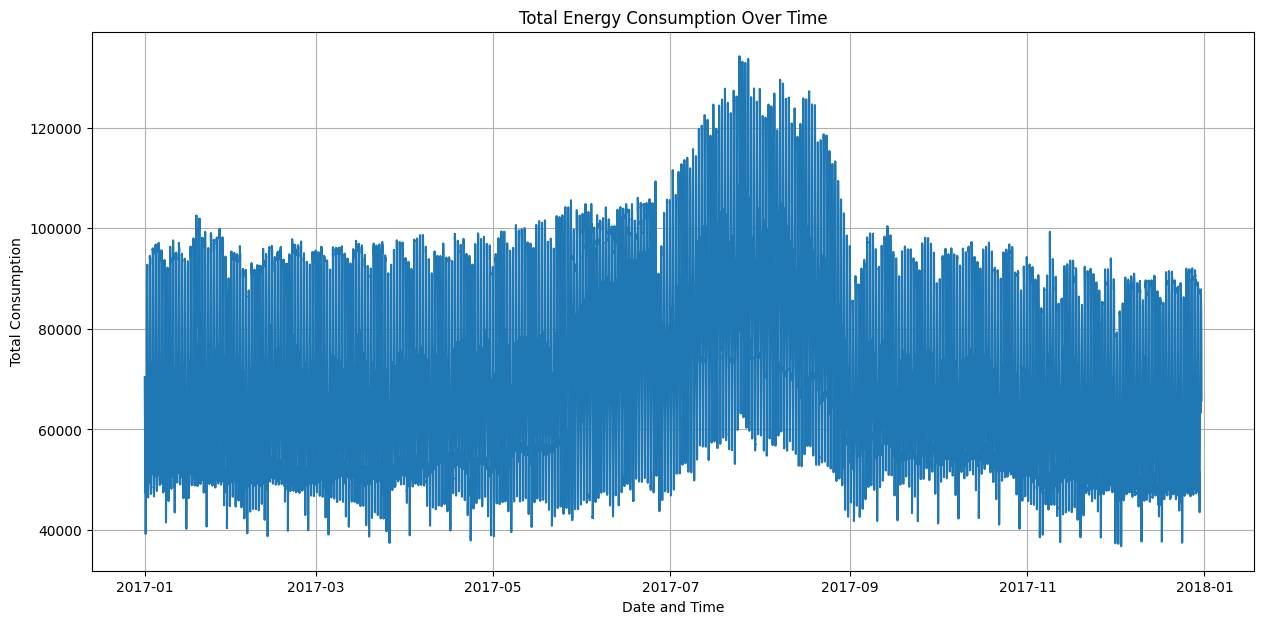

In [13]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

plt.figure(figsize=(15, 7))
sns.lineplot(x='Datetime', y='TotalConsumption', data=df)
plt.title('Total Energy Consumption Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Total Consumption')
plt.grid(True)
plt.show()

/tmp/ipykernel_28721/339063759.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.set_index('Datetime').resample('H')['TotalConsumption'].mean().reset_index()


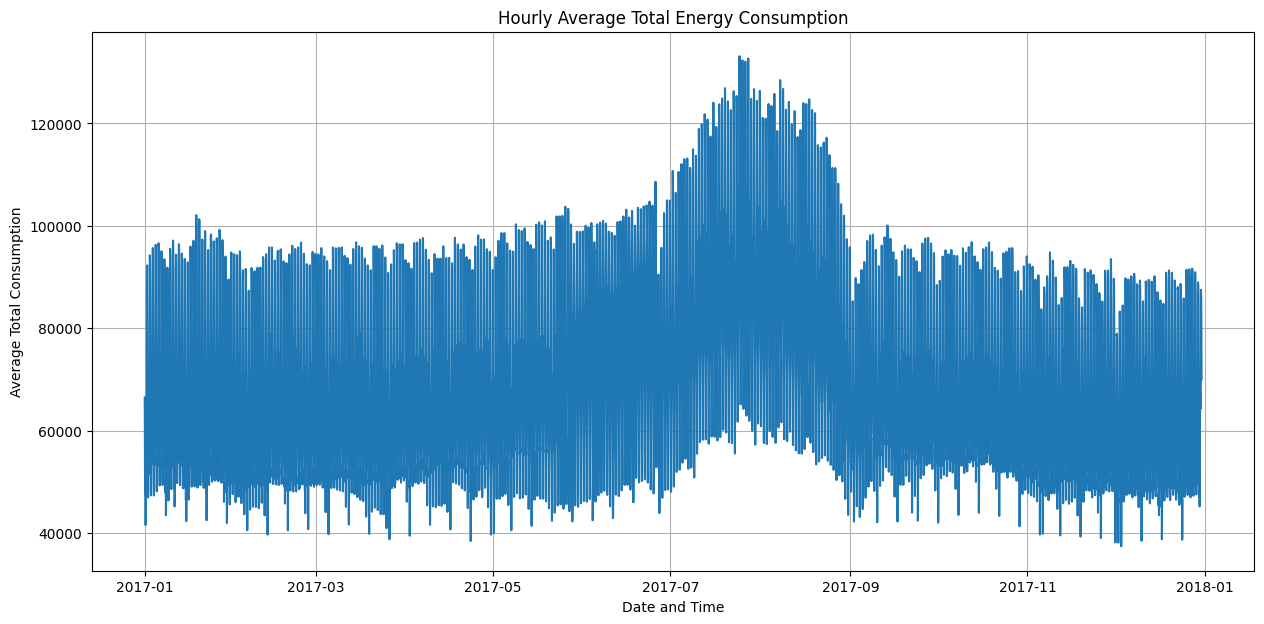

In [14]:
df_hourly = df.set_index('Datetime').resample('H')['TotalConsumption'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='Datetime', y='TotalConsumption', data=df_hourly)
plt.title('Hourly Average Total Energy Consumption')
plt.xlabel('Date and Time')
plt.ylabel('Average Total Consumption')
plt.grid(True)
plt.show()

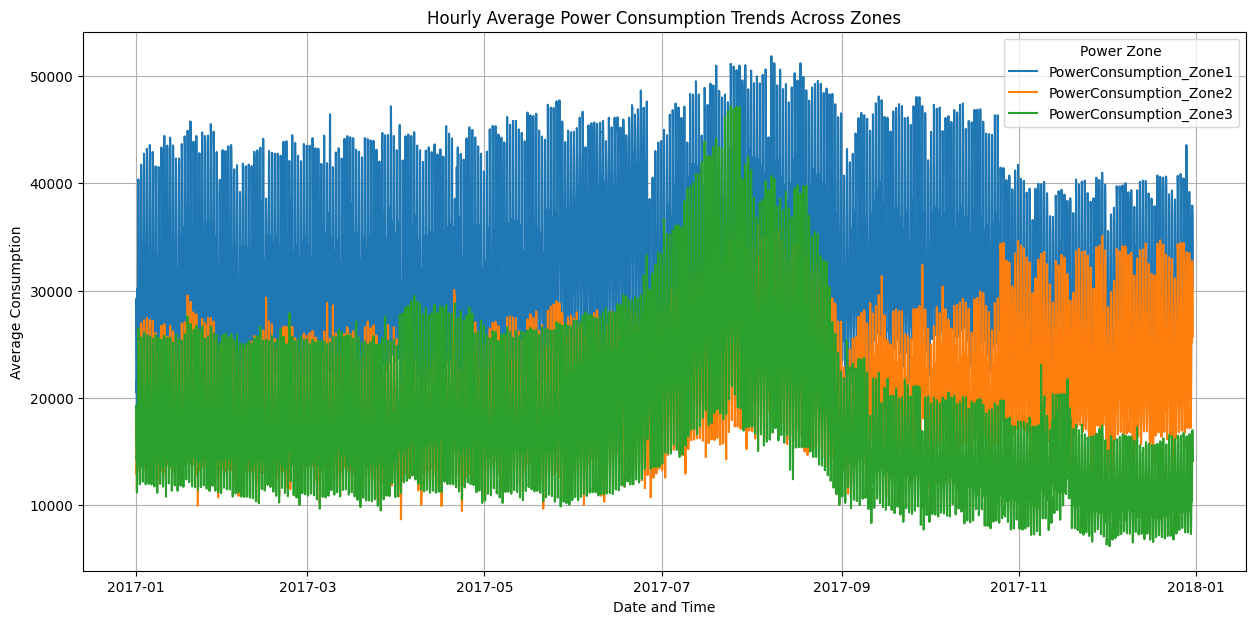

In [15]:
zones_df = df[['Datetime', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']].set_index('Datetime')

# Resample each zone by hour and calculate the mean
zones_hourly = zones_df.resample('h').mean().reset_index()

# Melt the DataFrame to a long format for plotting
zones_melted = zones_hourly.melt(id_vars=['Datetime'], var_name='Zone', value_name='Consumption')

plt.figure(figsize=(15, 7))
sns.lineplot(x='Datetime', y='Consumption', hue='Zone', data=zones_melted)
plt.title('Hourly Average Power Consumption Trends Across Zones')
plt.xlabel('Date and Time')
plt.ylabel('Average Consumption')
plt.grid(True)
plt.legend(title='Power Zone')
plt.show()

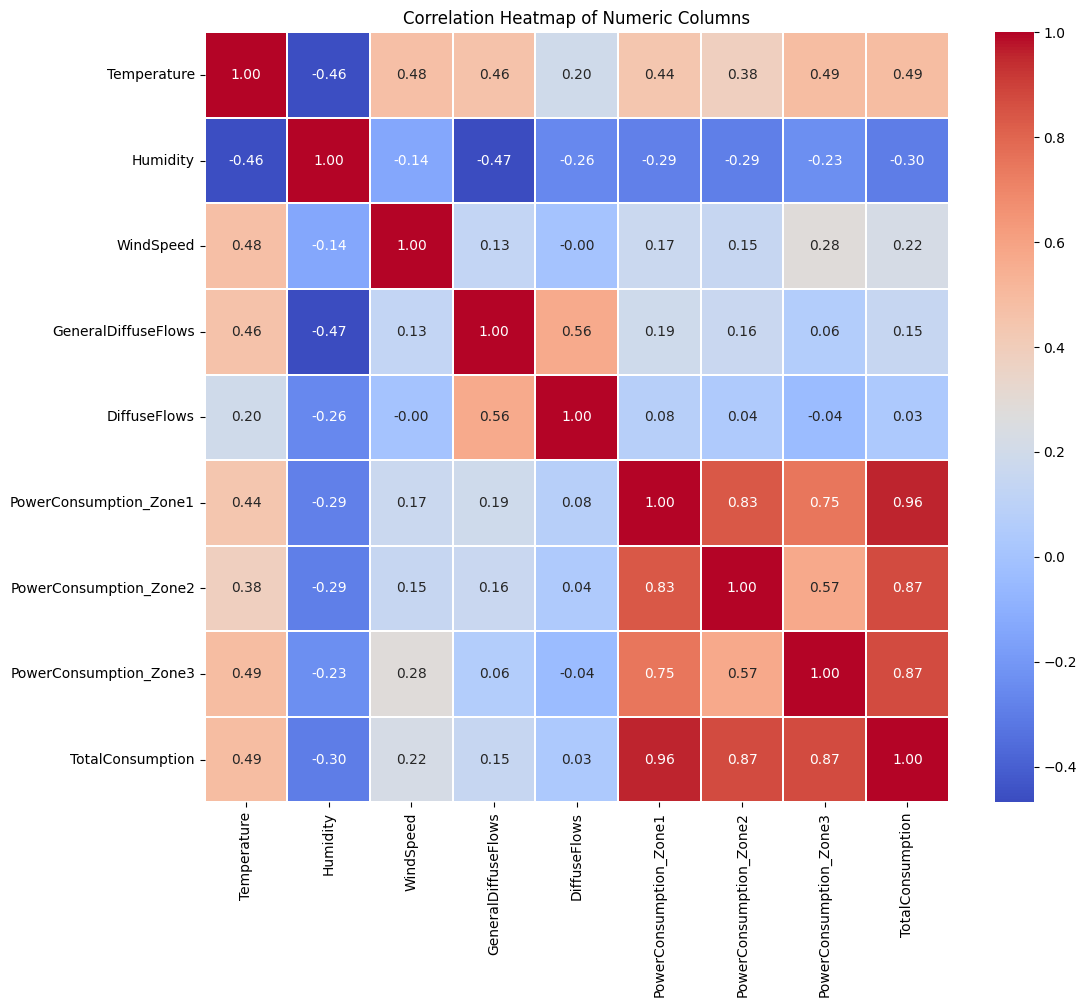

In [16]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.25)
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

In [17]:
df["lag_1"] = df["PowerConsumption_Zone1"].shift(1)
df["lag_6"] = df["PowerConsumption_Zone1"].shift(6)
df["lag_144"] = df["PowerConsumption_Zone1"].shift(144)
df["lag_1008"] = df["PowerConsumption_Zone1"].shift(1008)

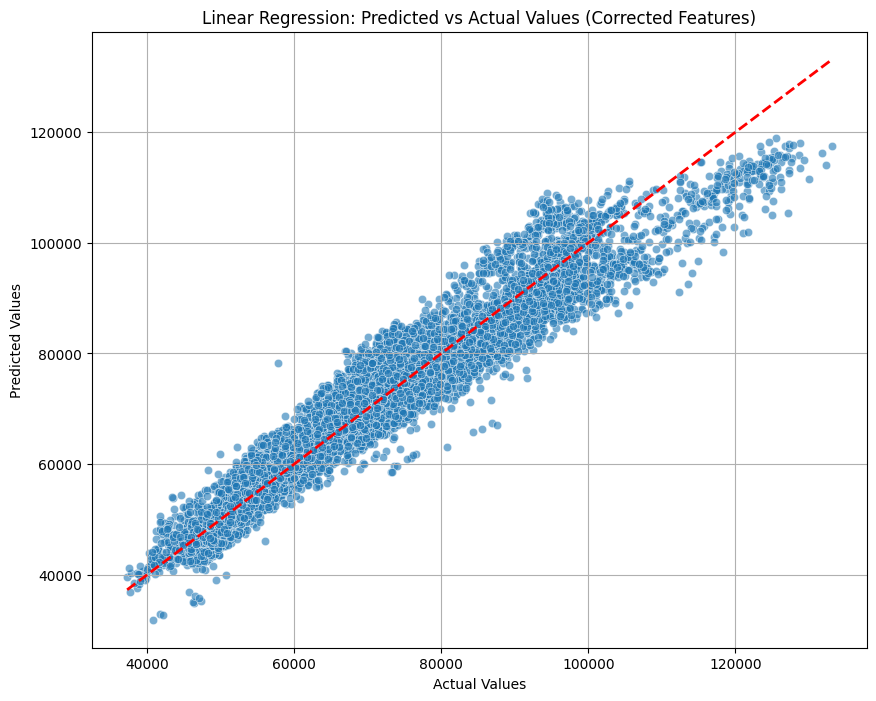

RMSE: 4536.38
R-squared: 0.9320


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows',
            'lag_1', 'lag_6', 'lag_144', 'lag_1008']
target = 'TotalConsumption'

# Ensure all features exist in the DataFrame
existing_features = [f for f in features if f in df.columns]
X = df[existing_features]
y = df[target]

# Handle NaN values introduced by lag features
# We'll drop rows with NaNs for simplicity, but more sophisticated methods could be used
data_for_model = pd.concat([X, y], axis=1).dropna()

X = data_for_model[existing_features]
y = data_for_model[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Plotting Predicted vs Actual Values
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Linear Regression: Predicted vs Actual Values (Corrected Features)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

# Print the metrics again
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.4f}")

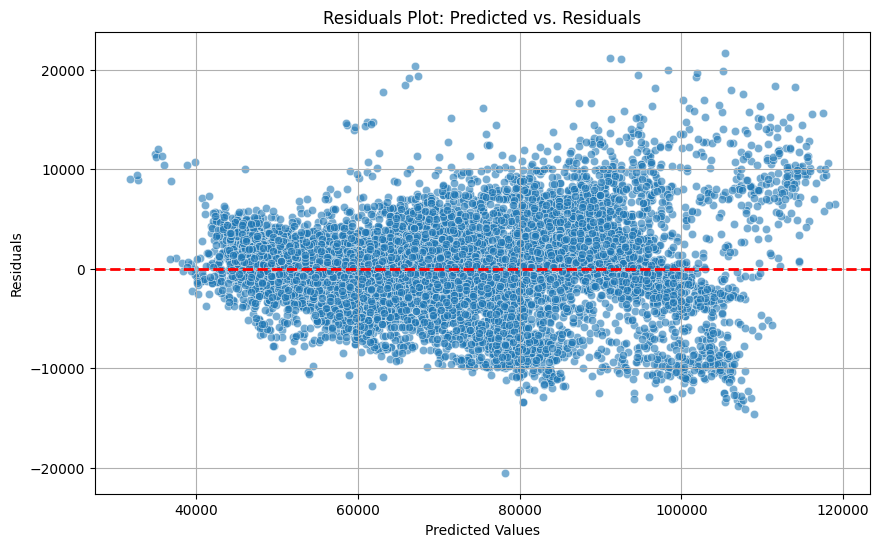

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Add a horizontal line at 0 for reference
plt.title('Residuals Plot: Predicted vs. Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

In [20]:
from sklearn.model_selection import KFold, cross_val_score

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

# Convert negative MSE to RMSE
cv_rmse_scores = np.sqrt(-cv_scores)

print(f"Cross-validation RMSE scores: {cv_rmse_scores}")
print(f"Mean RMSE: {cv_rmse_scores.mean():.2f}")
print(f"Standard Deviation of RMSE: {cv_rmse_scores.std():.2f}")

# Optionally, you can also get R-squared scores
cv_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
print(f"\nCross-validation R-squared scores: {cv_r2_scores}")
print(f"Mean R-squared: {cv_r2_scores.mean():.4f}")
print(f"Standard Deviation of R-squared: {cv_r2_scores.std():.4f}")

Cross-validation RMSE scores: [4536.37712283 4428.46128877 4477.59182101 4481.38328948 4462.95171726]
Mean RMSE: 4477.35
Standard Deviation of RMSE: 34.92

Cross-validation R-squared scores: [0.93199125 0.9331708  0.93083584 0.93258594 0.93113081]
Mean R-squared: 0.9319
Standard Deviation of R-squared: 0.0009


### RandomForestRegressor Model

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the RandomForestRegressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the RandomForest model
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForestRegressor RMSE: {rmse_rf:.2f}")
print(f"RandomForestRegressor R-squared: {r2_rf:.4f}")

RandomForestRegressor RMSE: 2048.85
RandomForestRegressor R-squared: 0.9861


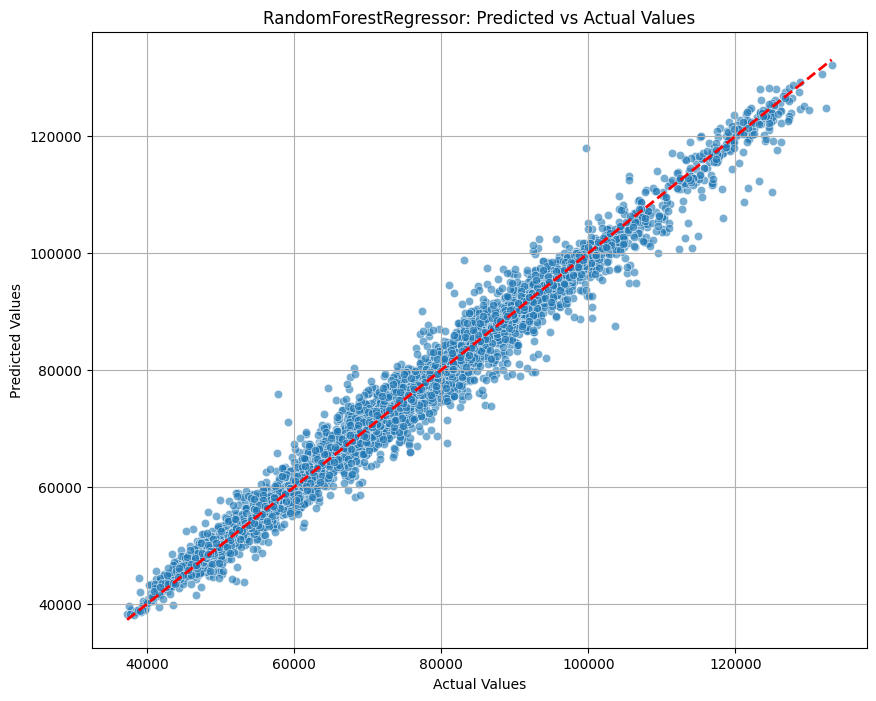

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('RandomForestRegressor: Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

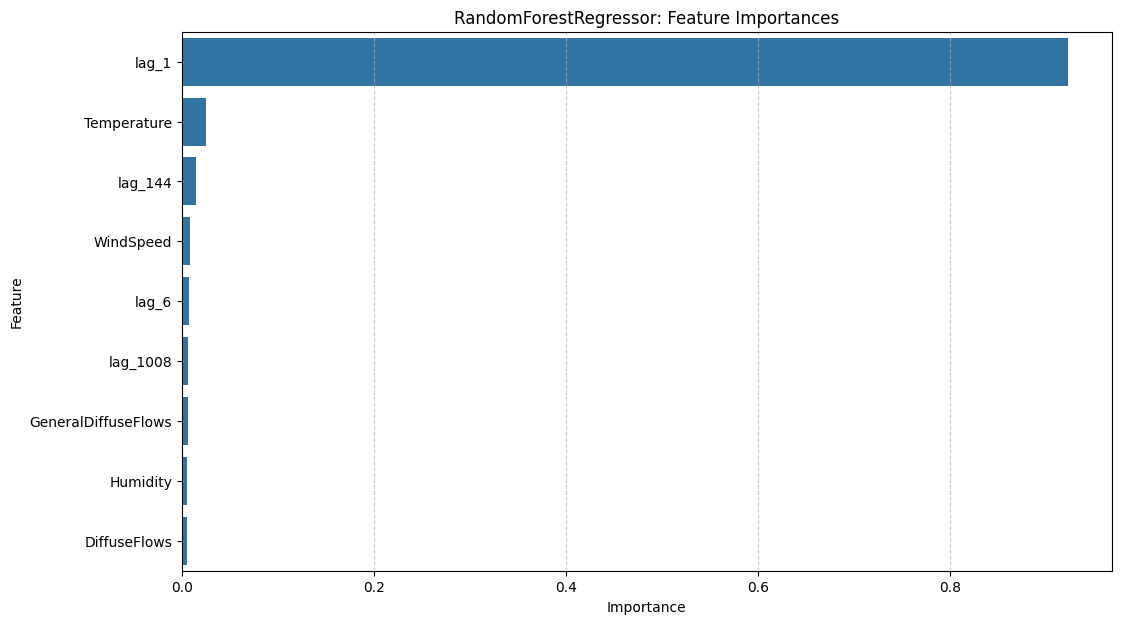

,Feature,Importance
5,lag_1,0.922228
0,Temperature,0.024955
7,lag_144,0.014325
2,WindSpeed,0.007931
6,lag_6,0.007530
8,lag_1008,0.006775
3,GeneralDiffuseFlows,0.005954
1,Humidity,0.005258
4,DiffuseFlows,0.005043


In [23]:
feature_importances = rf_model.feature_importances_
features = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('RandomForestRegressor: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(importance_df)

### XGBoost Regressor Model

In [24]:
from xgboost import XGBRegressor

# Initialize and train the XGBoost Regressor model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoostRegressor RMSE: {rmse_xgb:.2f}")
print(f"XGBoostRegressor R-squared: {r2_xgb:.4f}")

XGBoostRegressor RMSE: 2353.89
XGBoostRegressor R-squared: 0.9817


In [25]:
# Perform cross-validation for XGBoostRegressor
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse_scores_xgb = np.sqrt(-cv_scores_xgb)

print(f"\nXGBoostRegressor Cross-validation RMSE scores: {cv_rmse_scores_xgb}")
print(f"XGBoostRegressor Mean RMSE: {cv_rmse_scores_xgb.mean():.2f}")
print(f"XGBoostRegressor Standard Deviation of RMSE: {cv_rmse_scores_xgb.std():.2f}")

cv_r2_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2', n_jobs=-1)
print(f"\nXGBoostRegressor Cross-validation R-squared scores: {cv_r2_scores_xgb}")
print(f"XGBoostRegressor Mean R-squared: {cv_r2_scores_xgb.mean():.4f}")
print(f"XGBoostRegressor Standard Deviation of R-squared: {cv_r2_scores_xgb.std():.4f}")


XGBoostRegressor Cross-validation RMSE scores: [2356.57188011 2377.48245211 2371.95911505 2398.33358381 2362.47605753]
XGBoostRegressor Mean RMSE: 2373.36
XGBoostRegressor Standard Deviation of RMSE: 14.44

XGBoostRegressor Cross-validation R-squared scores: [0.98164697 0.98073827 0.98059085 0.98069164 0.98070186]
XGBoostRegressor Mean R-squared: 0.9809
XGBoostRegressor Standard Deviation of R-squared: 0.0004


### Updated Model Comparison Summary

**Linear Regression Model:**
- RMSE: 4536.38
- R-squared: 0.9320
- Mean Cross-validation RMSE: 4477.35
- Mean Cross-validation R-squared: 0.9319

**RandomForestRegressor Model:**
- RMSE: 2048.85
- R-squared: 0.9861
- Mean Cross-validation RMSE: 2070.35
- Mean Cross-validation R-squared: 0.9859

**XGBoostRegressor Model:**
- RMSE: 2353.89
- R-squared: 0.9817
- Mean Cross-validation RMSE: 2373.36
- Mean Cross-validation R-squared: 0.9809

**LSTM Model:**
- RMSE: 654.67
- R-squared: 0.9979

Based on these results, the **LSTM Model** is currently the best performing model, demonstrating a significantly lower RMSE and higher R-squared compared to the other models. This indicates that it captures the time-series patterns in the data more effectively.

### LSTM Model for Time Series Forecasting

In [26]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

# Combine features and target for scaling
# We'll use the same features and target as before, but for LSTM we need to scale them.
# The 'data_for_model' DataFrame already contains X and y aligned.

# Select the relevant columns for scaling
columns_to_scale = existing_features + [target]
df_scaled = data_for_model[columns_to_scale]

# Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler and transform the data
df_scaled_values = scaler.fit_transform(df_scaled)

# Create a scaler for the target variable specifically, for inverse transformation later
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(data_for_model[[target]])

print("Data scaled successfully.")

Data scaled successfully.


#### Creating Sequences for LSTM

In [27]:
# Function to create sequences for LSTM
def create_sequences(data, target_index, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        # Features are n_steps observations
        X.append(data[i:(i + n_steps), :])
        # Target is the next observation's target value
        y.append(data[i + n_steps, target_index])
    return np.array(X), np.array(y)

# Define the number of time steps (look-back period)
n_steps = 10  # This can be tuned later

# Get the index of the target variable in the scaled DataFrame
target_col_index = df_scaled.columns.get_loc(target)

# Create sequences for LSTM
X_lstm, y_lstm = create_sequences(df_scaled_values, target_col_index, n_steps)

print(f"Shape of X_lstm: {X_lstm.shape}")
print(f"Shape of y_lstm: {y_lstm.shape}")

# Split data into training and testing sets (for LSTM, often time-based split is preferred)
# For simplicity, we will use a train_test_split, but a time-aware split is better for time series
split_ratio = 0.8
split_index = int(len(X_lstm) * split_ratio)

X_train_lstm, X_test_lstm = X_lstm[:split_index], X_lstm[split_index:]
y_train_lstm, y_test_lstm = y_lstm[:split_index], y_lstm[split_index:]

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")

Shape of X_lstm: (51398, 10, 10)
Shape of y_lstm: (51398,)
X_train_lstm shape: (41118, 10, 10)
X_test_lstm shape: (10280, 10, 10)


#### Define and Train the LSTM Model

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1028/1028 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0026 - val_loss: 4.6175e-04
Epoch 2/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.4091e-04 - val_loss: 6.0256e-04
Epoch 3/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.9446e-04 - val_loss: 1.4994e-04
Epoch 4/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.3590e-04 - val_loss: 1.9910e-04
Epoch 5/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1.1510e-04 - val_loss: 1.3111e-04
Epoch 6/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 9.8405e-05 - val_loss: 7.1873e-05
Epoch 7/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 8.1419e-05 - val_loss: 6.7144e-05
Epoch 8/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 8.0136e-05 - val_loss: 8.1741e-05
Epoch 9/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7.2331e-05 - val_loss: 5.3134e-05
Epoch 10/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6.7737e-05 - val_loss: 6.2077e-05
Epoch 11/50
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/

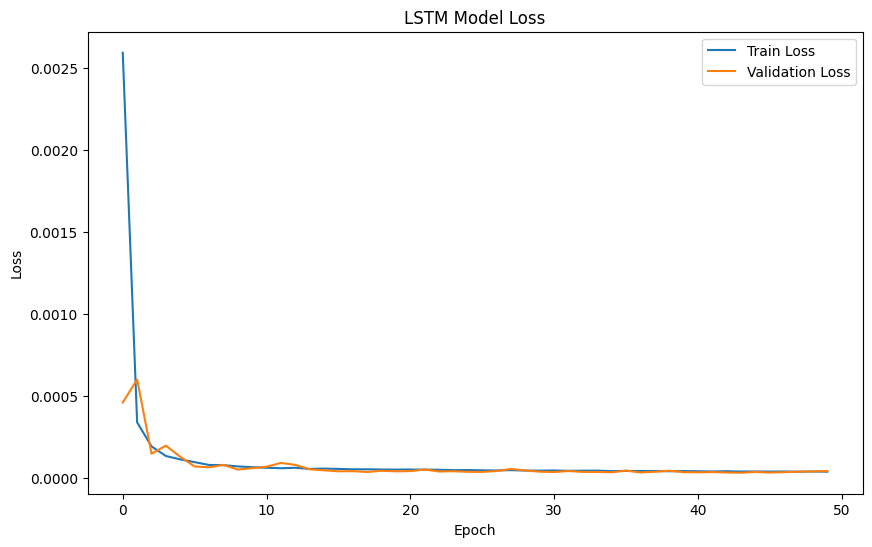

In [28]:
# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(n_steps, X_train_lstm.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train the model
history = lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### Evaluate the LSTM Model

In [29]:
# Make predictions on the test set
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)

# Inverse transform the predictions and actual values to their original scale
y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm_scaled)
y_test_lstm_original = target_scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

# Evaluate the LSTM model
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_original, y_pred_lstm))
r2_lstm = r2_score(y_test_lstm_original, y_pred_lstm)

print(f"LSTM RMSE: {rmse_lstm:.2f}")
print(f"LSTM R-squared: {r2_lstm:.4f}")

322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM RMSE: 610.71
LSTM R-squared: 0.9981


#### Visualize Actual vs. Predicted Values for LSTM

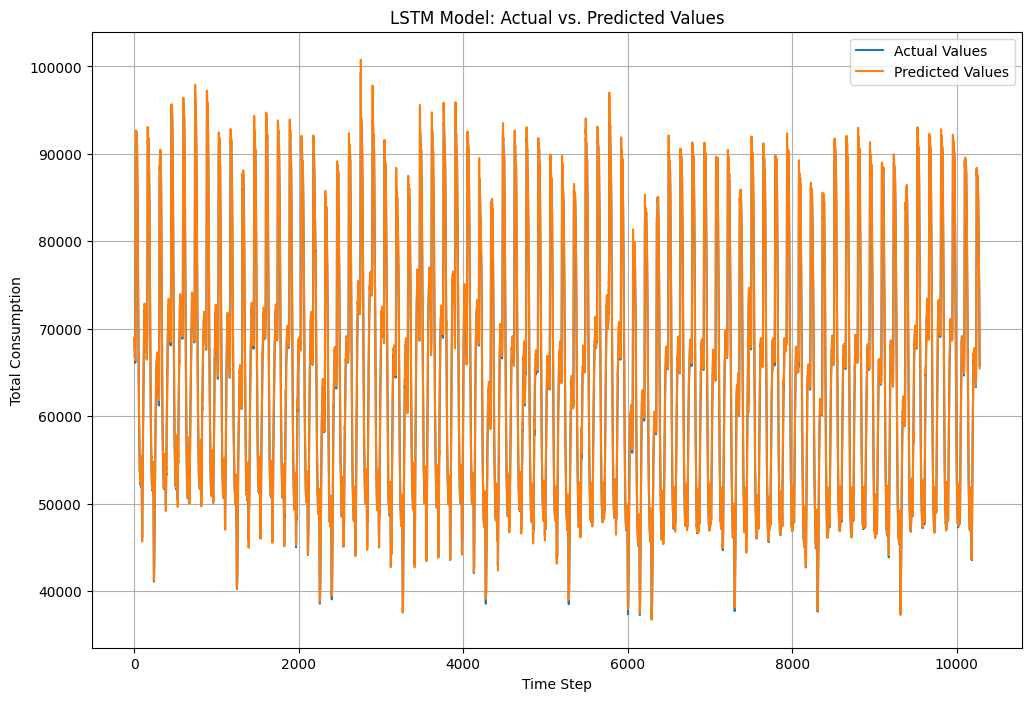

In [30]:
plt.figure(figsize=(12, 8))
plt.plot(y_test_lstm_original, label='Actual Values')
plt.plot(y_pred_lstm, label='Predicted Values')
plt.title('LSTM Model: Actual vs. Predicted Values')
plt.xlabel('Time Step')
plt.ylabel('Total Consumption')
plt.legend()
plt.grid(True)
plt.show()

### Save the Trained LSTM Model and Scalers

In [35]:
%%writefile requirements.txt
tensorflow
fastapi
uvicorn
pandas
scikit-learn
joblib

Overwriting requirements.txt


In [36]:
best_lstm_model.save('/content/energy_lstm_model.keras')

In [37]:
import joblib

joblib.dump(scaler, "/content/scaler.pkl")

['/content/scaler.pkl']

In [38]:
!pip install fastapi uvicorn nest-asyncio

### Load the Saved Model and Scalers for Prediction

In [39]:
import tensorflow as tf
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the saved LSTM model
loaded_lstm_model = tf.keras.models.load_model('/content/energy_lstm_model.keras')

# Load the scaler (features + target scaler)
loaded_scaler = joblib.load('/content/scaler.pkl')

# Re-create and fit the target_scaler for inverse transformation
# It was originally fitted on data_for_model[[target]]
target_scaler_for_inverse = MinMaxScaler(feature_range=(0, 1))
target_scaler_for_inverse.fit(data_for_model[['TotalConsumption']])

print("Model and scalers loaded successfully!")

Model and scalers loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [85]:
# Save the target_scaler_for_inverse to the expected path
import joblib
joblib.dump(target_scaler_for_inverse, "/content/target_scaler_for_inverse.pkl")
print("target_scaler_for_inverse saved successfully to /content/target_scaler_for_inverse.pkl")

target_scaler_for_inverse saved successfully to /content/target_scaler_for_inverse.pkl


In [89]:
import gradio as gr
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model("energy_lstm_model.keras")

def predict_energy(values):
    x = np.array(values, dtype=np.float32)

    if x.shape != (10, 10):
        return f"Expected 10 × 10 input, got {x.shape}"

    x = x.reshape(1, 10, 10)

    prediction = model.predict(x, verbose=0)

    return float(prediction[0][0])


demo = gr.Interface(
    fn=predict_energy,
    inputs=gr.Dataframe(
        headers=[f"Feature_{i+1}" for i in range(4)],
        datatype=["number"] * 10,
        type="numpy",
        row_count=10,
        col_count=(10, "fixed")
    ),
    outputs=gr.Number(label="Predicted Consumption"),
    title="Smart Energy Consumption Predictor",
    description="LSTM-based electricity consumption forecasting"
)

demo.launch()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/gradio/components/dataframe.py:192: UserWarning: The `col_count` parameter is deprecated and will be removed. Please use `column_count` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://15d726c0cf942fd036.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [93]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 57.0 MB/s eta 0:00:00


In [94]:
import streamlit as st
import tensorflow as tf

st.title("⚡ Smart Energy Consumption Predictor")

model = tf.keras.models.load_model("energy_lstm_model.keras")

st.success("LSTM model loaded successfully")

st.write("Model input shape:", model.input_shape)

2026-08-20 07:48:30.308 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 07:48:31.029 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-20 07:48:31.031 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 07:48:31.032 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-08-20 07:48:31.150 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-20 07:48:31.151 Thr